In [ ]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
import numpy as np
import matplotlib.pyplot as plt


def draw_landmarks_on_image(rgb_image, detection_result):
  face_landmarks_list = detection_result.face_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected faces to visualize - i.e. process each person 1 by 1
  for idx in range(len(face_landmarks_list)):
    face_landmarks = face_landmarks_list[idx]

    # Draw the face landmarks.


    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION, # Tesselation layer -> creates 3D mesh over skin
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_tesselation_style())
    
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS, # Contours layer -> draw distinct outline paths around major features 
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_contours_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS, # Left Iris Layer -> connects dots in tiny circle around left iris 
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS, # Right Iris Layer -> connects dots in tiny circle around right iris 
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())

  return annotated_image

def plot_face_blendshapes_bar_graph(face_blendshapes):
  # Extract the face blendshapes category names and scores.
  face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
  face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
  # The blendshapes are ordered in decreasing score value.
  face_blendshapes_ranks = range(len(face_blendshapes_names))

  fig, ax = plt.subplots(figsize=(12, 12))
  bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
  ax.set_yticks(face_blendshapes_ranks, face_blendshapes_names)
  ax.invert_yaxis()

  # Label each bar with values
  for score, patch in zip(face_blendshapes_scores, bar.patches):
    plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

  ax.set_xlabel('Score')
  ax.set_title("Face Blendshapes")
  plt.tight_layout()
  plt.show()

In [ ]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an FaceLandmarker object.
base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=5)
detector = vision.FaceLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("obama-face.jpeg")

# STEP 4: Detect face landmarks from the input image.
detection_result = detector.detect(image)

# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
cv2.imshow("Facial Landmarks", cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))

cv2.waitKey(0)           # Tells the OS to freeze the window open until you press ANY key
cv2.destroyAllWindows()  # Safely closes the GUI memory threads when a key is pressed

W0000 00:00:1779230146.458539  464752 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779230146.465907  464752 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779230146.470932  464768 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-U)
W0000 00:00:1779230146.477286  464754 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779230146.508073  464760 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


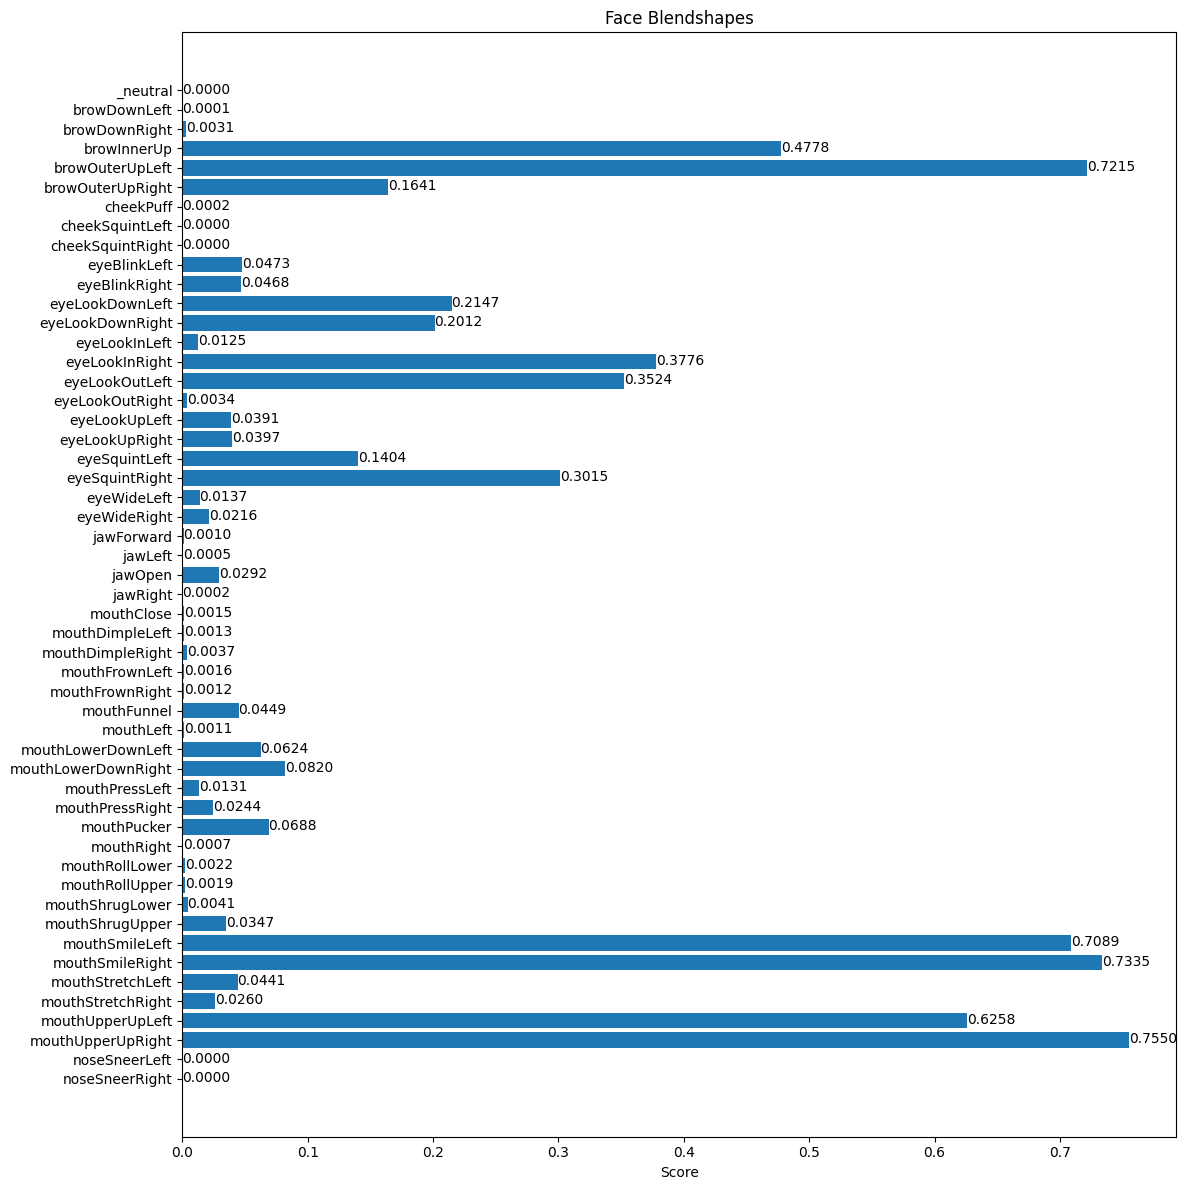

In [8]:
# Bar graph of facial expression features - the score represents the ratio of the expression to its theoretical maximum
plot_face_blendshapes_bar_graph(detection_result.face_blendshapes[0])

In [ ]:
# test: seeing multiple faces
print(detection_resu;lt)

In [ ]:


def draw_circle(img, x_pos, y_pos):
    print(type(img))
    cv2.circle(
        img=img,
        center=(x_pos, y_pos),
        radius=5,
        color=(0, 255, 0),
        thickness=1
    )
    return None


def process_faces(faces):
    
    cols = 3 if len(faces) > 2 else 1 
    rows = np.ceil(len(faces)/cols).astype(int)

    figs, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))    
    if len(faces) > 1: axes = axes.flatten()


    for idx in range(len(faces)):

        print(f"index: {idx}\n")
        img = cv2.imread(faces[idx])
        img_w, img_h = img.shape[1], img.shape[0]

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        )

        detection_result = detector.detect(mp_image)

        face = detection_result.face_landmarks[0]

        left_eye_center = face[468]

        left_eye_x = int(left_eye_center.x * img_w)
        left_eye_y = int(left_eye_center.y * img_h)

        right_eye_center = face[473]
        right_eye_x = int(right_eye_center.x * img_w)
        right_eye_y = int(right_eye_center.y * img_h)

        nose_tip = face[4]
        nose_tip_x = int(nose_tip.x * img_w)
        nose_tip_y = int(nose_tip.y * img_h)

        # FACE BOX

        FACE_OVAL = [
            10, 338, 297, 332, 284, 251, 389, 356,
            454, 323, 361, 288, 397, 365, 379, 378,
            400, 377, 152, 148, 176, 149, 150, 136,
            172, 58, 132, 93, 234, 127, 162, 21,
            54, 103, 67, 109
        ]

        oval_points = []

        for face_idx in FACE_OVAL:
            lm = face[face_idx]

            x = int(lm.x * img_w)
            y = int(lm.y * img_h)

            oval_points.append([x, y])

        oval_points = np.array(oval_points)
        
        # Draw outline
        cv2.drawContours(
        img,
        [oval_points],
        -1,
        (255, 0, 0),
        2
        ) 
                
        left_eye = (left_eye_x , left_eye_y)
        right_eye = (right_eye_x, right_eye_y)
        nose = (nose_tip_x, nose_tip_y)


        # source points
        src = np.array([
            left_eye,
            right_eye,
            nose
        ], dtype=np.float32)

        new_left_eye = (40, 40)
        new_right_eye = (85, 40)
        new_nose = (63, 70)

        # where we want to transform to
        dst = np.array([
            new_left_eye, 
            new_right_eye,
            new_nose
        ], dtype=np.float32)
        
        M, _ = cv2.estimateAffinePartial2D(src, dst)

        aligned_img = cv2.warpAffine(img, M, (125, 125))

        img_rgb = cv2.cvtColor(aligned_img, cv2.COLOR_BGR2RGB)


        if len(faces) > 1:
            axes[idx].imshow(img_rgb)
        else:
            axes.imshow(img_rgb)



index: 0

index: 1

index: 2

index: 3

index: 4

index: 5

index: 6

index: 7



IndexError: list index out of range

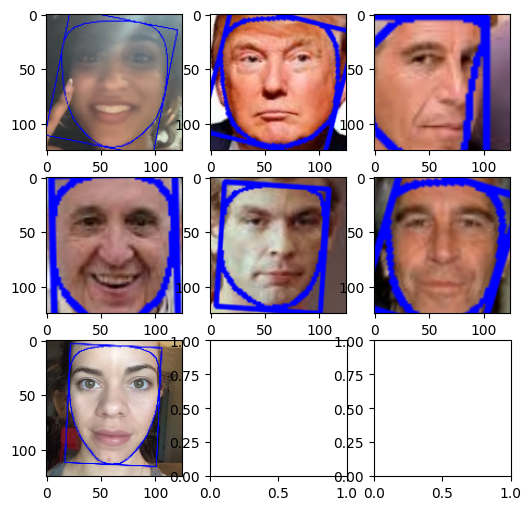

In [7]:
process_faces(['taz.jpg', 'trump-face.jpeg', 'jeff1.jpeg', 'pope.jpeg', 'jeffDahm.jpeg', 'jeff2.jpeg', 'asymmetrix.webp', 'obama-face.jpeg'])